# E-commerce Customer Behavior Analysis

Segment customers across app, web, and store channels using clustering analysis. Identify high-value segments, channel preferences, and retention risk to drive targeted retention and personalization strategies.

**Methods:** K-Means, Hierarchical, DBSCAN clustering | **Data:** 360 synthetic e-commerce customers | **Output:** Segment profiles, prediction model, business recommendations

## 1. Import Python Libraries

In [1]:
from pathlib import Path
import sys
import warnings

warnings.filterwarnings("ignore")

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display
from sklearn.cluster import AgglomerativeClustering, DBSCAN, KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score

project_root = Path.cwd().resolve()
for candidate in [project_root, *project_root.parents]:
    if (candidate / "src").exists():
        project_root = candidate
        break

src_path = project_root / "src"
if str(src_path) not in sys.path:
    sys.path.insert(0, str(src_path))

from segmentation_utils import (
    CATEGORICAL_FEATURES,
    NUMERIC_FEATURES,
    attach_segment_names,
    build_preprocessor,
    normalize_column_names,
    predict_cluster_label,
    save_customer_dataset,
    validate_customer_data,
)

sns.set_theme(style="whitegrid", context="talk")
pd.set_option("display.max_columns", 100)

## 2. Load the Base Customer Dataset

The project starts from a reproducible retail customer base. If the CSV does not exist yet, the notebook creates it first so the workflow stays self-contained.

In [4]:
data_path = project_root / "data" / "customer_segmentation_enhanced.csv"

if not data_path.exists():
    raw_customers = save_customer_dataset(data_path, n_customers=360, random_state=42)
else:
    raw_customers = pd.read_csv(data_path)

raw_customers = normalize_column_names(raw_customers)
raw_customers = validate_customer_data(raw_customers)

display(raw_customers.head())
print("Shape:", raw_customers.shape)
print("Null values:\n", raw_customers.isna().sum().sort_values(ascending=False).head(10))
print("\nSummary:\n")
display(raw_customers.describe(include="all").T)

,customer_id,gender,age,annual_income_k,spending_score,app_sessions_per_week,online_orders_per_month,store_visits_per_month,promo_response_rate,loyalty_months,family_size,city_tier,preferred_channel,seasonal_spending_index,returns_rate,order_value_avg,membership_tier,monthly_spend_k
0,1225,Female,37,89.1,59,10.4,5.2,4.3,0.321,25,2,Tier 2,App,0.964,0.086,22.67,Silver,37.8
1,1043,Female,28,91.7,68,7.0,2.2,6.8,0.436,21,3,Tier 3,Store,0.858,0.080,32.67,Silver,36.5
2,1286,Female,30,68.6,58,8.5,2.4,5.3,0.339,9,5,Tier 2,Website,0.781,0.083,23.28,Bronze,32.6
3,1303,Male,46,50.3,52,8.4,3.9,9.1,0.386,13,2,Tier 2,Store,0.854,0.121,16.54,Silver,30.6
4,1057,Male,33,98.1,42,9.0,9.1,1.5,0.253,16,5,Tier 1,App,0.996,0.081,20.67,Silver,38.3


Shape: (360, 18)
Null values:
 customer_id                0
gender                     0
age                        0
annual_income_k            0
spending_score             0
app_sessions_per_week      0
online_orders_per_month    0
store_visits_per_month     0
promo_response_rate        0
loyalty_months             0
dtype: int64

Summary:



,count,unique,top,freq,mean,std,min,25%,50%,75%,max
customer_id,360.0,NaN,NaN,NaN,1180.5,104.067286,1001.0,1090.75,1180.5,1270.25,1360.0
gender,360,3,Female,177,NaN,NaN,NaN,NaN,NaN,NaN,NaN
age,360.0,NaN,NaN,NaN,36.116667,10.928624,18.0,28.0,36.0,43.0,70.0
annual_income_k,360.0,NaN,NaN,NaN,70.369722,23.8365,22.0,53.175,69.95,85.525,134.3
spending_score,360.0,NaN,NaN,NaN,52.116667,14.725823,2.0,43.0,53.0,61.25,94.0
app_sessions_per_week,360.0,NaN,NaN,NaN,7.765278,2.928144,0.8,5.8,7.65,9.625,16.6
online_orders_per_month,360.0,NaN,NaN,NaN,4.144444,2.157651,0.0,2.5,3.9,5.5,10.0
store_visits_per_month,360.0,NaN,NaN,NaN,6.440556,2.852858,0.0,4.3,6.4,8.5,15.2
promo_response_rate,360.0,NaN,NaN,NaN,0.397272,0.101195,0.084,0.3345,0.3975,0.466,0.661
loyalty_months,360.0,NaN,NaN,NaN,20.441667,12.874017,1.0,11.0,18.0,26.0,72.0


## 3. Create a More Unique Dataset with Additional Features

The notebook adds extra behavioral signals so the final project is not just a mall customer clone. These features capture digital behavior, family context, seasonal buying patterns, and value sensitivity.

In [3]:
customers = raw_customers.copy()

customers["digital_affinity"] = (
    customers["app_sessions_per_week"] * 0.65
    + customers["online_orders_per_month"] * 0.85
    + customers["promo_response_rate"] * 15
).round(2)
customers["store_vs_digital_ratio"] = (
    customers["store_visits_per_month"] / (customers["online_orders_per_month"] + 1)
).round(3)
customers["value_per_visit"] = (
    customers["monthly_spend_k"] / (customers["store_visits_per_month"] + customers["online_orders_per_month"] + 1)
).round(2)
customers["engagement_band"] = pd.cut(
    customers["digital_affinity"],
    bins=[-np.inf, 8, 15, np.inf],
    labels=["Low", "Medium", "High"],
)

customers = customers.replace([np.inf, -np.inf], np.nan).dropna().reset_index(drop=True)
display(customers.head())
print("Shape after feature engineering:", customers.shape)

,customer_id,gender,age,annual_income_k,spending_score,app_sessions_per_week,online_orders_per_month,store_visits_per_month,promo_response_rate,loyalty_months,family_size,city_tier,preferred_channel,seasonal_spending_index,returns_rate,order_value_avg,membership_tier,monthly_spend_k,digital_affinity,store_vs_digital_ratio,value_per_visit,engagement_band
0,1225,Female,37,89.1,59,10.4,5.2,4.3,0.321,25,2,Tier 2,App,0.964,0.086,22.67,Silver,37.8,16.00,0.694,3.60,High
1,1043,Female,28,91.7,68,7.0,2.2,6.8,0.436,21,3,Tier 3,Store,0.858,0.080,32.67,Silver,36.5,12.96,2.125,3.65,Medium
2,1286,Female,30,68.6,58,8.5,2.4,5.3,0.339,9,5,Tier 2,Website,0.781,0.083,23.28,Bronze,32.6,12.65,1.559,3.75,Medium
3,1303,Male,46,50.3,52,8.4,3.9,9.1,0.386,13,2,Tier 2,Store,0.854,0.121,16.54,Silver,30.6,14.57,1.857,2.19,Medium
4,1057,Male,33,98.1,42,9.0,9.1,1.5,0.253,16,5,Tier 1,App,0.996,0.081,20.67,Silver,38.3,17.38,0.149,3.30,High


Shape after feature engineering: (360, 22)


## 4. Clean and Validate the Data

A small dirty copy is created on purpose to show the cleaning workflow: duplicates are removed, missing values are filled, column names are standardized, and numeric ranges are checked.

In [5]:
dirty = customers.copy()

missing_indices = dirty.sample(3, random_state=7).index
dirty.loc[missing_indices, "promo_response_rate"] = np.nan
dirty = pd.concat([dirty, dirty.iloc[[0]]], ignore_index=True)
dirty.columns = dirty.columns.str.strip().str.lower().str.replace(" ", "_", regex=False)

cleaned = dirty.drop_duplicates(subset=["customer_id"]).copy()
for column in cleaned.columns:
    if pd.api.types.is_numeric_dtype(cleaned[column]) and column != "customer_id":
        cleaned[column] = cleaned[column].fillna(cleaned[column].median())

cleaned["engagement_band"] = cleaned["engagement_band"].astype("object")
cleaned["engagement_band"] = cleaned["engagement_band"].fillna(cleaned["engagement_band"].mode()[0])
cleaned = validate_customer_data(cleaned)

display(cleaned.head())
print("Shape after cleaning:", cleaned.shape)
print("Remaining null values:\n", cleaned.isna().sum().sort_values(ascending=False).head(10))

,customer_id,gender,age,annual_income_k,spending_score,app_sessions_per_week,online_orders_per_month,store_visits_per_month,promo_response_rate,loyalty_months,family_size,city_tier,preferred_channel,seasonal_spending_index,returns_rate,order_value_avg,membership_tier,monthly_spend_k,digital_affinity,store_vs_digital_ratio,value_per_visit,engagement_band
0,1225,Female,37,89.1,59,10.4,5.2,4.3,0.321,25,2,Tier 2,App,0.964,0.086,22.67,Silver,37.8,16.00,0.694,3.60,High
1,1043,Female,28,91.7,68,7.0,2.2,6.8,0.436,21,3,Tier 3,Store,0.858,0.080,32.67,Silver,36.5,12.96,2.125,3.65,Medium
2,1286,Female,30,68.6,58,8.5,2.4,5.3,0.339,9,5,Tier 2,Website,0.781,0.083,23.28,Bronze,32.6,12.65,1.559,3.75,Medium
3,1303,Male,46,50.3,52,8.4,3.9,9.1,0.386,13,2,Tier 2,Store,0.854,0.121,16.54,Silver,30.6,14.57,1.857,2.19,Medium
4,1057,Male,33,98.1,42,9.0,9.1,1.5,0.253,16,5,Tier 1,App,0.996,0.081,20.67,Silver,38.3,17.38,0.149,3.30,High


Shape after cleaning: (360, 22)
Remaining null values:
 customer_id                0
gender                     0
age                        0
annual_income_k            0
spending_score             0
app_sessions_per_week      0
online_orders_per_month    0
store_visits_per_month     0
promo_response_rate        0
loyalty_months             0
dtype: int64


## 5. Encode Categorical Columns and Scale Numeric Features

Clustering works best when numeric values are scaled and categories are encoded consistently. The preprocessing pipeline is reused later for prediction.

In [6]:
numeric_features = NUMERIC_FEATURES + ["digital_affinity", "store_vs_digital_ratio", "value_per_visit"]
categorical_features = CATEGORICAL_FEATURES + ["engagement_band"]
selected_feature_columns = numeric_features + categorical_features

feature_frame = cleaned[selected_feature_columns].copy()
preprocessor = build_preprocessor(numeric_features, categorical_features)
X = preprocessor.fit_transform(feature_frame)
feature_names = preprocessor.get_feature_names_out()

print("Transformed matrix shape:", X.shape)
print("Feature columns:", len(selected_feature_columns))
print("Encoded feature count:", len(feature_names))

Transformed matrix shape: (360, 31)
Feature columns: 20
Encoded feature count: 31


## 6. Perform Exploratory Data Analysis

The EDA focuses on age, income, spend behavior, loyalty, and the balance between online and store activity.

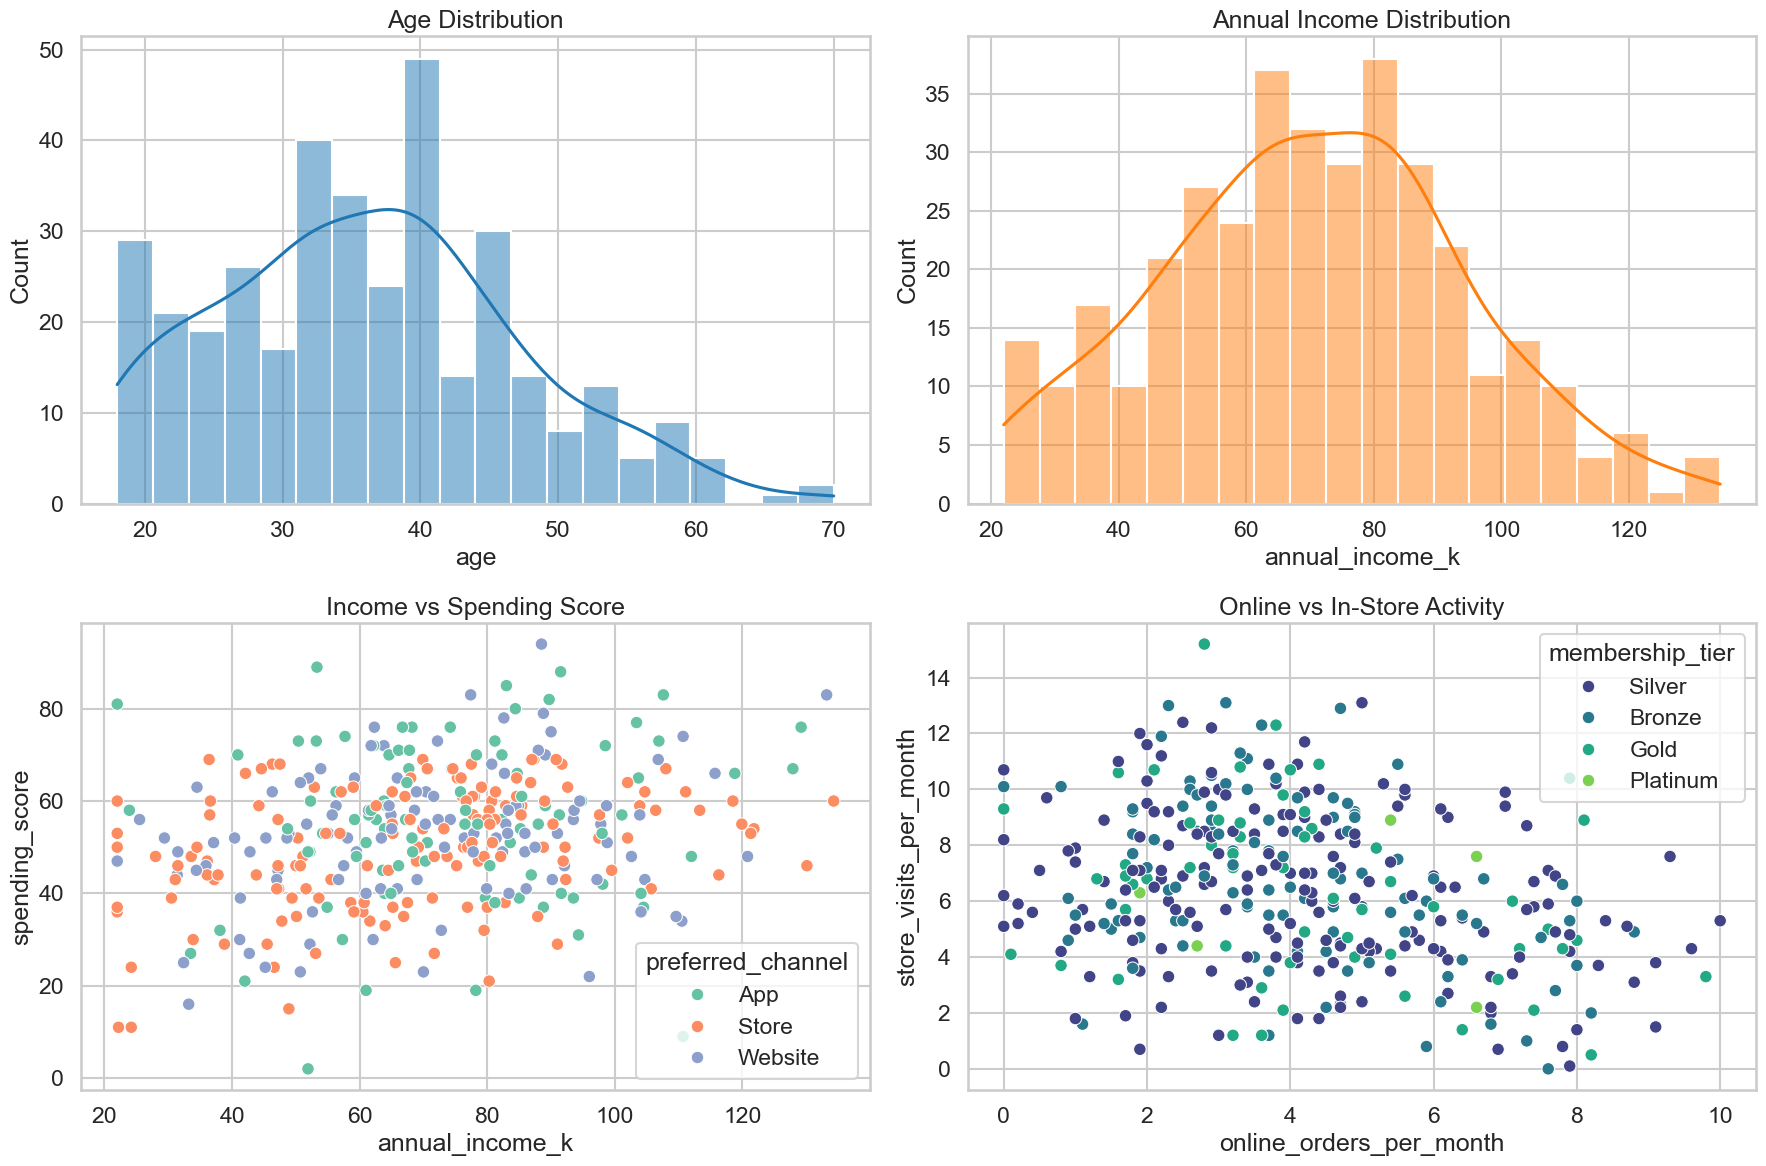

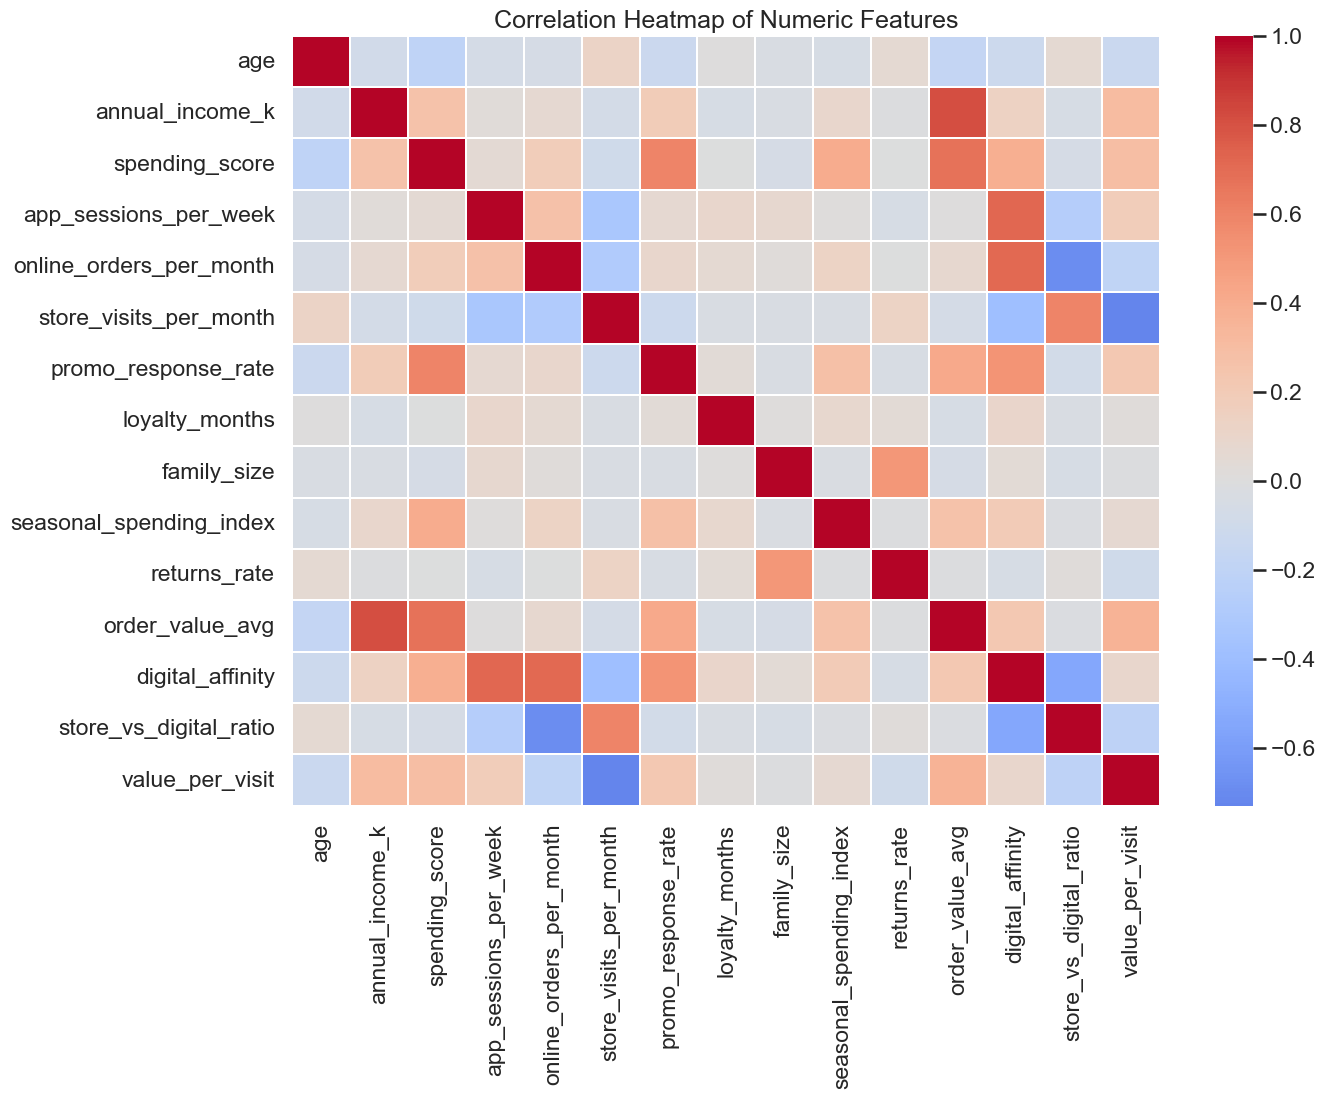

In [7]:
fig, axes = plt.subplots(2, 2, figsize=(18, 12))

sns.histplot(cleaned["age"], bins=20, kde=True, ax=axes[0, 0], color="#1f77b4")
axes[0, 0].set_title("Age Distribution")

sns.histplot(cleaned["annual_income_k"], bins=20, kde=True, ax=axes[0, 1], color="#ff7f0e")
axes[0, 1].set_title("Annual Income Distribution")

sns.scatterplot(
    data=cleaned,
    x="annual_income_k",
    y="spending_score",
    hue="preferred_channel",
    palette="Set2",
    ax=axes[1, 0],
)
axes[1, 0].set_title("Income vs Spending Score")

sns.scatterplot(
    data=cleaned,
    x="online_orders_per_month",
    y="store_visits_per_month",
    hue="membership_tier",
    palette="viridis",
    ax=axes[1, 1],
)
axes[1, 1].set_title("Online vs In-Store Activity")

plt.tight_layout()
plt.show()

corr = cleaned[numeric_features].corr(numeric_only=True)
plt.figure(figsize=(14, 10))
sns.heatmap(corr, cmap="coolwarm", center=0, linewidths=0.3)
plt.title("Correlation Heatmap of Numeric Features")
plt.show()

## 7. Select Features for Segmentation

The selected feature set keeps the segmentation grounded in business behavior rather than raw noise. A quick variance and correlation check helps justify the final input space.

In [8]:
variance_check = cleaned[numeric_features].var(numeric_only=True).sort_values(ascending=False)
high_corr_pairs = (
    corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))
    .stack()
    .sort_values(ascending=False)
)

print("Top variance features:\n", variance_check.head(8))
print("\nHighest correlations:\n", high_corr_pairs.head(8))

selected_numeric_features = numeric_features
selected_categorical_features = categorical_features
print("Selected numeric features:", selected_numeric_features)
print("Selected categorical features:", selected_categorical_features)

Top variance features:
 annual_income_k           568.178719
spending_score            216.849861
loyalty_months            165.740320
age                       119.434819
order_value_avg            75.228751
digital_affinity           11.997537
app_sessions_per_week       8.574028
store_visits_per_month      8.138796
dtype: float64

Highest correlations:
 annual_income_k          order_value_avg           0.814801
app_sessions_per_week    digital_affinity          0.719942
online_orders_per_month  digital_affinity          0.712949
spending_score           order_value_avg           0.673598
                         promo_response_rate       0.595958
store_visits_per_month   store_vs_digital_ratio    0.595155
promo_response_rate      digital_affinity          0.521408
family_size              returns_rate              0.508123
dtype: float64
Selected numeric features: ['age', 'annual_income_k', 'spending_score', 'app_sessions_per_week', 'online_orders_per_month', 'store_visits_per_mont

## 8. Estimate the Best Number of Clusters

The elbow curve and silhouette score provide two views of how many customer segments are reasonable for this dataset.

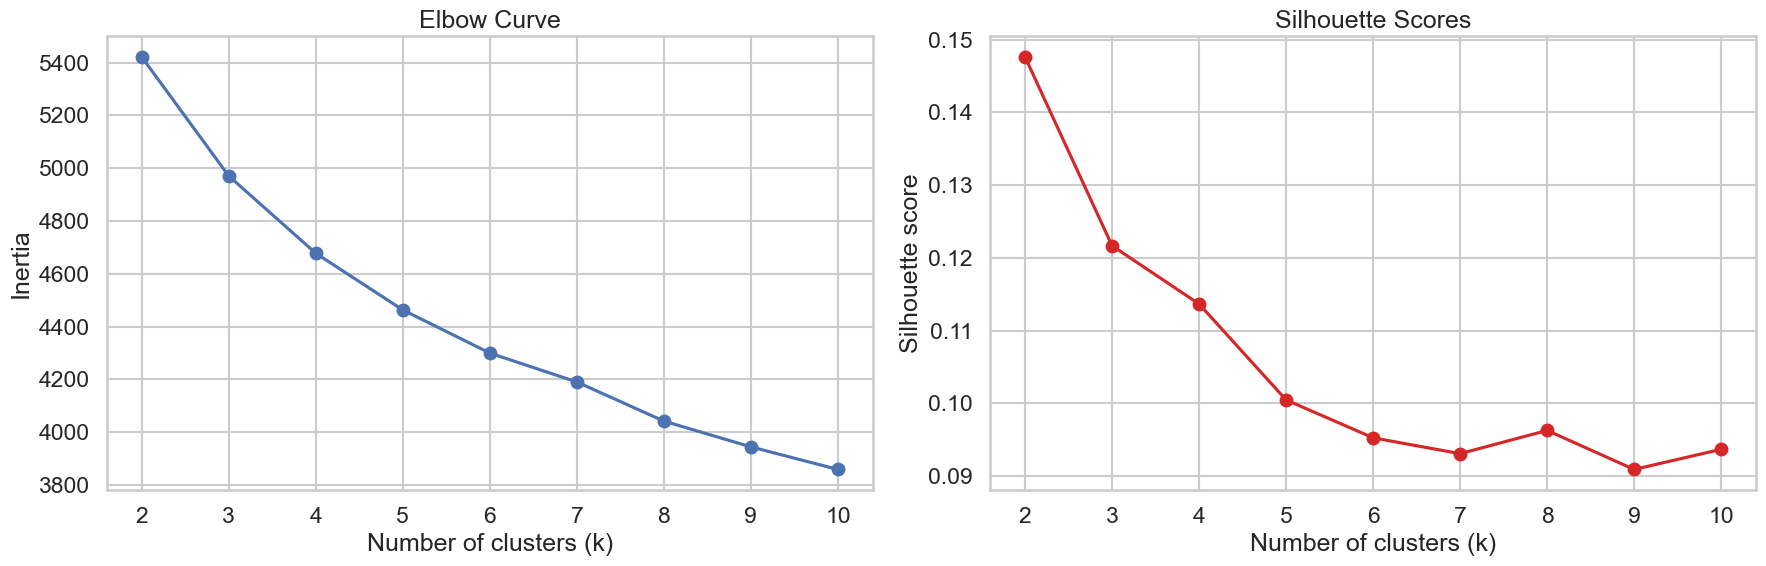

Best k by silhouette score: 2


In [9]:
k_values = range(2, 11)
inertias = []
silhouette_scores = []

for k in k_values:
    model = KMeans(n_clusters=k, random_state=42, n_init=20)
    labels = model.fit_predict(X)
    inertias.append(model.inertia_)
    silhouette_scores.append(silhouette_score(X, labels))

fig, axes = plt.subplots(1, 2, figsize=(18, 6))
axes[0].plot(list(k_values), inertias, marker="o")
axes[0].set_title("Elbow Curve")
axes[0].set_xlabel("Number of clusters (k)")
axes[0].set_ylabel("Inertia")

axes[1].plot(list(k_values), silhouette_scores, marker="o", color="#d62728")
axes[1].set_title("Silhouette Scores")
axes[1].set_xlabel("Number of clusters (k)")
axes[1].set_ylabel("Silhouette score")

plt.tight_layout()
plt.show()

best_k = int(list(k_values)[int(np.argmax(silhouette_scores))])
print("Best k by silhouette score:", best_k)

## 9. Train a K-Means Segmentation Model

K-Means is the primary segmentation method in the project. The final cluster labels are written back into the dataset for profiling and export.

In [10]:
kmeans = KMeans(n_clusters=5, random_state=42, n_init=20)
cleaned["kmeans_cluster"] = kmeans.fit_predict(X)

kmeans_silhouette = silhouette_score(X, cleaned["kmeans_cluster"])
print("K-Means silhouette score:", round(kmeans_silhouette, 4))
display(cleaned[["customer_id", "kmeans_cluster"]].head())

K-Means silhouette score: 0.1005


,customer_id,kmeans_cluster
0,1225,0
1,1043,4
2,1286,3
3,1303,1
4,1057,0


## 10. Compare with Hierarchical Clustering

Hierarchical clustering offers a centroid-free alternative for comparison, revealing tree-based cluster relationships not visible in K-Means.

In [11]:
agglomerative = AgglomerativeClustering(n_clusters=5, linkage="ward")
cleaned["hierarchical_cluster"] = agglomerative.fit_predict(X)

hierarchical_silhouette = silhouette_score(X, cleaned["hierarchical_cluster"])
comparison_table = pd.DataFrame(
    {
        "model": ["KMeans", "Agglomerative"],
        "silhouette_score": [kmeans_silhouette, hierarchical_silhouette],
    }
)
display(comparison_table)

,model,silhouette_score
0,KMeans,0.100471
1,Agglomerative,0.071060


## 11. Test Density-Based Clustering

DBSCAN helps identify compact groups and outliers. It is useful when some customers do not fit the main segment structure.

In [14]:
dbscan_input = PCA(n_components=2, random_state=42).fit_transform(X)
dbscan = DBSCAN(eps=0.55, min_samples=6)
cleaned["dbscan_cluster"] = dbscan.fit_predict(dbscan_input)

unique_dbscan_labels = set(cleaned["dbscan_cluster"])
valid_dbscan_labels = [label for label in unique_dbscan_labels if label != -1]
if len(valid_dbscan_labels) > 1:
    dbscan_score = silhouette_score(
        dbscan_input[cleaned["dbscan_cluster"] != -1],
        cleaned.loc[cleaned["dbscan_cluster"] != -1, "dbscan_cluster"],
    )
else:
    dbscan_score = np.nan

print("DBSCAN labels:", sorted(unique_dbscan_labels))
print("DBSCAN silhouette score:", dbscan_score)
print("Noise points:", int((cleaned["dbscan_cluster"] == -1).sum()))

DBSCAN labels: [-1, 0, 1]
DBSCAN silhouette score: 0.3268624356720943
Noise points: 44


## 12. Reduce Dimensions for Cluster Visualization

PCA makes it easier to see the customer groups in two dimensions and compare how the clustering algorithms separate the data.

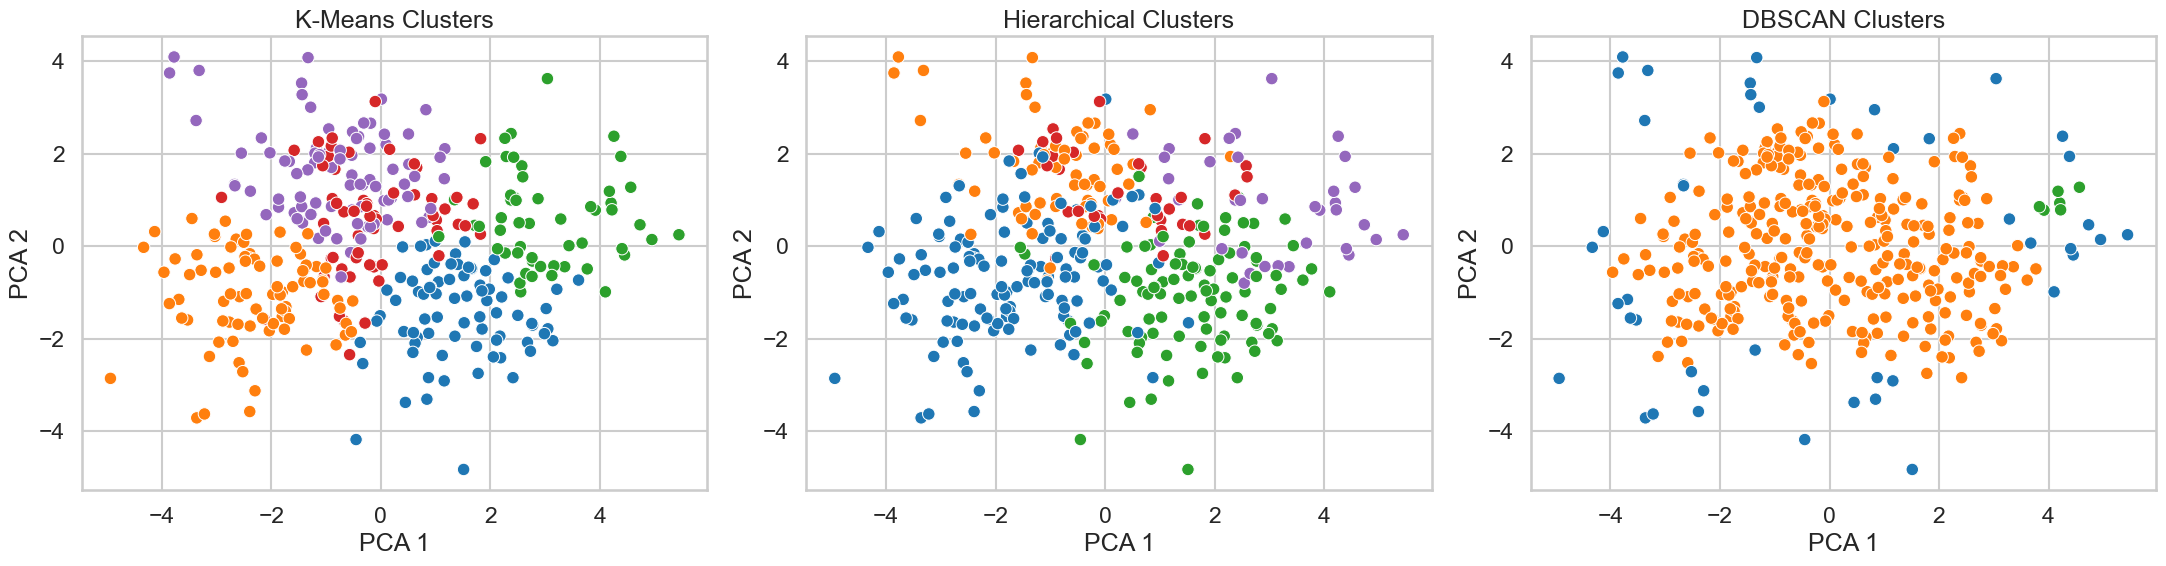

Explained variance ratio: [0.23  0.135]


In [15]:
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X)
pca_df = pd.DataFrame(X_pca, columns=["pca_1", "pca_2"])
pca_df = pd.concat([pca_df, cleaned[["kmeans_cluster", "hierarchical_cluster", "dbscan_cluster"]].reset_index(drop=True)], axis=1)

fig, axes = plt.subplots(1, 3, figsize=(22, 6))

sns.scatterplot(data=pca_df, x="pca_1", y="pca_2", hue="kmeans_cluster", palette="tab10", ax=axes[0], legend=False)
axes[0].set_title("K-Means Clusters")

sns.scatterplot(data=pca_df, x="pca_1", y="pca_2", hue="hierarchical_cluster", palette="tab10", ax=axes[1], legend=False)
axes[1].set_title("Hierarchical Clusters")

sns.scatterplot(data=pca_df, x="pca_1", y="pca_2", hue="dbscan_cluster", palette="tab10", ax=axes[2], legend=False)
axes[2].set_title("DBSCAN Clusters")

for ax in axes:
    ax.set_xlabel("PCA 1")
    ax.set_ylabel("PCA 2")

plt.tight_layout()
plt.show()

print("Explained variance ratio:", pca.explained_variance_ratio_.round(3))

## 13. Profile and Name Customer Segments

The segment names below are business-focused labels derived from cluster profiles. Use these to communicate findings to stakeholders and inform strategy.

In [16]:
def mode_value(series):
    modes = series.mode()
    return modes.iloc[0] if not modes.empty else np.nan

cluster_profile = (
    cleaned.groupby("kmeans_cluster")
    .agg(
        customer_count=("customer_id", "count"),
        age_mean=("age", "mean"),
        income_mean=("annual_income_k", "mean"),
        spending_score_mean=("spending_score", "mean"),
        digital_affinity_mean=("digital_affinity", "mean"),
        loyalty_months_mean=("loyalty_months", "mean"),
        family_size_mean=("family_size", "mean"),
        online_orders_mean=("online_orders_per_month", "mean"),
        store_visits_mean=("store_visits_per_month", "mean"),
        promo_response_mean=("promo_response_rate", "mean"),
        preferred_channel_mode=("preferred_channel", mode_value),
        membership_tier_mode=("membership_tier", mode_value),
    )
    .sort_values("spending_score_mean", ascending=False)
)

display(cluster_profile.round(2))

cluster_order = cluster_profile.index.tolist()
segment_name_map = {
    cluster_order[0]: "Premium Loyal Customers",
    cluster_order[1]: "High-Spend Omnichannel Buyers",
    cluster_order[2]: "Digital-first Professionals",
    cluster_order[3]: "Discount-driven Families",
    cluster_order[4]: "Value Seekers",
}

cleaned = attach_segment_names(cleaned.assign(kmeans_cluster=cleaned["kmeans_cluster"]), cluster_col="kmeans_cluster")
cleaned["segment_name"] = cleaned["kmeans_cluster"].map(segment_name_map)

display(cleaned[["customer_id", "kmeans_cluster", "segment_name"]].head())

,customer_count,age_mean,income_mean,spending_score_mean,digital_affinity_mean,loyalty_months_mean,family_size_mean,online_orders_mean,store_visits_mean,promo_response_mean,preferred_channel_mode,membership_tier_mode
kmeans_cluster,,,,,,,,,,,,
2,53,32.28,85.48,71.38,18.64,19.19,2.51,6.28,4.36,0.48,App,Silver
4,87,34.92,83.54,57.68,12.76,20.36,2.78,3.20,8.91,0.42,Store,Silver
3,59,35.29,73.49,50.29,12.62,20.59,2.88,2.24,4.33,0.38,Website,Silver
0,78,35.32,65.03,49.54,17.81,23.62,3.32,5.87,4.85,0.41,App,Silver
1,83,41.16,49.71,37.71,12.04,18.24,3.12,3.50,8.17,0.31,Store,Silver


,customer_id,kmeans_cluster,segment_name
0,1225,0,Discount-driven Families
1,1043,4,High-Spend Omnichannel Buyers
2,1286,3,Digital-first Professionals
3,1303,1,Value Seekers
4,1057,0,Discount-driven Families


## 14. Build a Segment Prediction Function

This helper makes the project reusable. A new customer record can be passed into the same preprocessing pipeline and the model will return a segment label.

In [17]:
model_bundle = {
    "preprocessor": preprocessor,
    "model": kmeans,
    "feature_columns": selected_feature_columns,
}

def predict_segment(new_customer: dict | pd.DataFrame) -> dict:
    if isinstance(new_customer, dict):
        new_customer = pd.DataFrame([new_customer])
    candidate = new_customer.copy()
    missing_columns = [column for column in selected_feature_columns if column not in candidate.columns]
    if missing_columns:
        raise ValueError(f"Missing required columns: {missing_columns}")
    predicted_cluster = predict_cluster_label(model_bundle, candidate)
    return {
        "cluster": predicted_cluster,
        "segment_name": segment_name_map.get(predicted_cluster, "Emerging Segment"),
    }

sample_customer = cleaned[selected_feature_columns].iloc[[0]].copy()
print(predict_segment(sample_customer))

{'cluster': 0, 'segment_name': 'Discount-driven Families'}


## 15. Export the Final Dataset and Model Artifacts

Export all outputs for downstream use: segmented customer data, cluster profiles, trained model bundle, and visualizations for reporting.

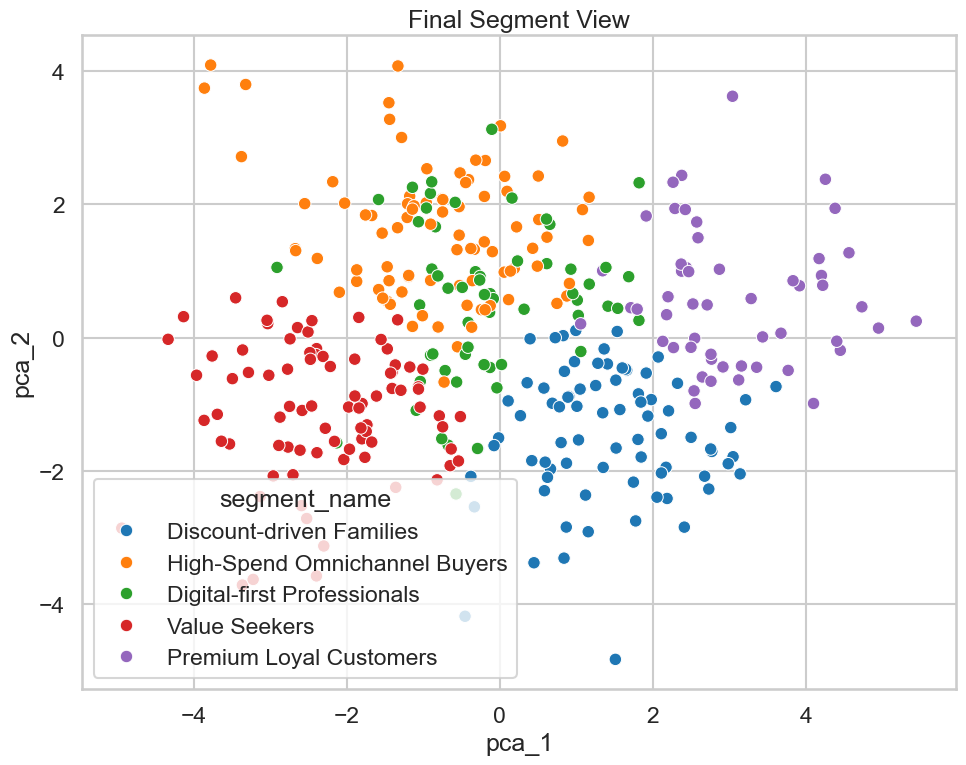

Saved:
C:\Users\touch\retail-customer-intelligence\data\customer_segmentation_final.csv
C:\Users\touch\retail-customer-intelligence\reports\cluster_profile.csv
C:\Users\touch\retail-customer-intelligence\reports\artifacts\segmentation_model_bundle.joblib
C:\Users\touch\retail-customer-intelligence\reports\pca_cluster_view.png
C:\Users\touch\retail-customer-intelligence\reports\project_summary.md


In [ ]:
reports_dir = project_root / "reports"
artifacts_dir = reports_dir / "artifacts"
artifacts_dir.mkdir(parents=True, exist_ok=True)

final_dataset_path = project_root / "data" / "customer_segmentation_final.csv"
profile_path = reports_dir / "cluster_profile.csv"
model_path = artifacts_dir / "segmentation_model_bundle.joblib"
pca_plot_path = reports_dir / "pca_cluster_view.png"
summary_path = reports_dir / "project_summary.md"

cleaned.to_csv(final_dataset_path, index=False)
cluster_profile.to_csv(profile_path)
joblib.dump(model_bundle, model_path)

summary_text = f"""# Customer Behavior Analysis Results

Segmentation of {len(cleaned)} e-commerce customers using K-Means, Hierarchical, and Density-Based clustering.

## Clustering Performance
- K-Means silhouette score: {kmeans_silhouette:.4f}
- Agglomerative silhouette score: {hierarchical_silhouette:.4f}
- DBSCAN silhouette score: {dbscan_score if not np.isnan(dbscan_score) else 'N/A'}

## Customer Segments
{chr(10).join([f'- Cluster {cluster}: {name}' for cluster, name in segment_name_map.items()])}
"""
summary_path.write_text(summary_text, encoding="utf-8")

fig = plt.figure(figsize=(10, 8))
ax = plt.gca()
sns.scatterplot(data=pca_df, x="pca_1", y="pca_2", hue=cleaned["segment_name"], palette="tab10", ax=ax)
ax.set_title("Final Segment View")
plt.tight_layout()
plt.savefig(pca_plot_path, dpi=160, bbox_inches="tight")
plt.show()

print("Saved:")
print(final_dataset_path)
print(profile_path)
print(model_path)
print(pca_plot_path)
print(summary_path)

# Next Steps

Use the trained model and segment profiles to:
- **Target campaigns** by segment using the prediction function on new customers
- **Personalize product recommendations** based on channel preference and spending patterns
- **Optimize retention** by identifying and engaging low-frequency or at-risk segments
- **Expand the model** with larger datasets or real production data for ongoing analysis